In [8]:
r = [0.012 , -0.008, 0.003]
w = [0.4, 0.35, 0.25]

retorno = r[0]* w[0] + r[1]* w[1] + r[2]* w[2]
print(round(retorno))

0


In [33]:
import numpy as np
import yfinance as yf

# Descarga 1 año de datos
tickers = ["AAPL", "TSLA", "AMZN" ,"GLD"]
data = yf.download(tickers, start="2024-01-01", end="2024-12-31")["Close"]

# Calcula retornos logarítmicos
returns = np.log(data / data.shift(1)).dropna()

# Vector de pesos
w = np.array([0.40, 0.20, 0.25, 0.15])

# Retorno promedio diario del portafolio
r_portfolio = returns @ w
print("Retorno diario promedio:", r_portfolio.mean().round(5))

# Matriz de covarianza
cov_matrix = returns.cov()
print("\nMatriz de covarianza:")
print(cov_matrix.round(6))

# Riesgo del portafolio (varianza)
portfolio_variance = w.T @ cov_matrix.values @ w
portfolio_std = np.sqrt(portfolio_variance) * np.sqrt(252)  # anualizada
print("\nVolatilidad anualizada del portafolio:", round(portfolio_std * 100, 2), "%")

# Retorno anualizado del portafolio
retorno_anualizado = r_portfolio.mean() * 252
print("Retorno anualizado del portafolio:", round(retorno_anualizado * 100, 2), "%")

# Sharpe Ratio (retorno / riesgo)
sharpe = retorno_anualizado / portfolio_std
print("Sharpe Ratio:", round(sharpe, 2))

[*********************100%***********************]  4 of 4 completed

Retorno diario promedio: 0.00135

Matriz de covarianza:
Ticker      AAPL      AMZN       GLD      TSLA
Ticker                                        
AAPL    0.000198  0.000085  0.000017  0.000188
AMZN    0.000085  0.000315  0.000025  0.000227
GLD     0.000017  0.000025  0.000090  0.000019
TSLA    0.000188  0.000227  0.000019  0.001557

Volatilidad anualizada del portafolio: 18.93 %
Retorno anualizado del portafolio: 34.11 %
Sharpe Ratio: 1.8


In [35]:
import subprocess
subprocess.run(["git", "add", "."])
subprocess.run(["git", "commit", "-m", "W1D1 homework: added GLD, Sharpe improved 1.51→1.80"])
subprocess.run(["git", "push"])


CompletedProcess(args=['git', 'push'], returncode=0)

## Dia 2 PCA y eigenvectores

[**********************75%***********            ]  3 of 4 completed

Eigenvalores: [1.626e-03 2.980e-04 1.500e-04 8.700e-05]

Varianza explicada por cada componente:
  PC1: 75.3%
  PC2: 13.8%
  PC3: 6.9%
  PC4: 4.0%

Primer eigenvector (PC1):
  AAPL: -0.1389
  TSLA: -0.1780
  AMZN: -0.0166
  GLD: -0.9740


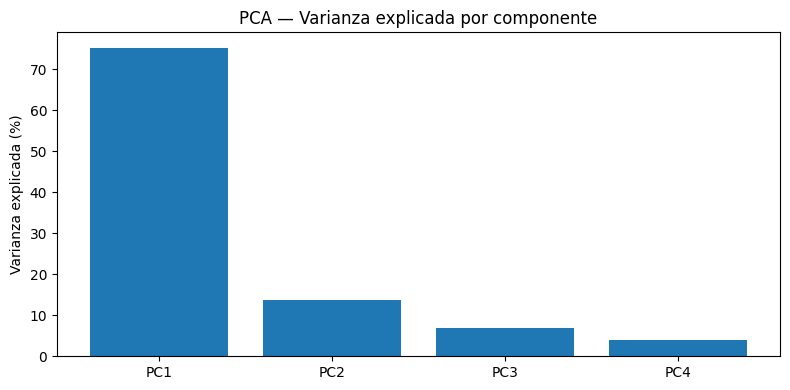

Varianza explicada (correlación):
  PC1: 43.0%
  PC2: 24.2%
  PC3: 16.5%
  PC4: 16.3%

Primer eigenvector (PC1):
  AAPL: -0.5673
  TSLA: -0.5663
  AMZN: -0.2569
  GLD: -0.5399


In [37]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf

# Mismos datos de ayer
tickers = ["AAPL", "TSLA", "AMZN", "GLD"]
data = yf.download(tickers, start="2024-01-01", end="2024-12-31")["Close"]
returns = np.log(data / data.shift(1)).dropna()

# Matriz de covarianza
cov_matrix = returns.cov().values

# Eigenvalores y eigenvectores
eigenvalues, eigenvectors = np.linalg.eig(cov_matrix)

# Ordenar de mayor a menor
idx = eigenvalues.argsort()[::-1]
eigenvalues = eigenvalues[idx]
eigenvectors = eigenvectors[:, idx]

# Varianza explicada por cada componente
varianza_explicada = eigenvalues / eigenvalues.sum() * 100

print("Eigenvalores:", eigenvalues.round(6))
print("\nVarianza explicada por cada componente:")
for i, v in enumerate(varianza_explicada):
    print(f"  PC{i+1}: {v:.1f}%")

print("\nPrimer eigenvector (PC1):")
for ticker, peso in zip(tickers, eigenvectors[:, 0]):
    print(f"  {ticker}: {peso:.4f}")

# Gráfica
plt.figure(figsize=(8, 4))
plt.bar([f"PC{i+1}" for i in range(len(eigenvalues))], varianza_explicada)
plt.ylabel("Varianza explicada (%)")
plt.title("PCA — Varianza explicada por componente")
plt.tight_layout()
plt.show()

# PCA correcto — sobre matriz de correlación
corr_matrix = returns.corr().values

eigenvalues_c, eigenvectors_c = np.linalg.eig(corr_matrix)

idx = eigenvalues_c.argsort()[::-1]
eigenvalues_c = eigenvalues_c[idx]
eigenvectors_c = eigenvectors_c[:, idx]

varianza_explicada_c = eigenvalues_c / eigenvalues_c.sum() * 100

print("Varianza explicada (correlación):")
for i, v in enumerate(varianza_explicada_c):
    print(f"  PC{i+1}: {v:.1f}%")

print("\nPrimer eigenvector (PC1):")
for ticker, peso in zip(tickers, eigenvectors_c[:, 0]):
    print(f"  {ticker}: {peso:.4f}")

## Mini proyecto del dia

Proyectar retornos sobre PCA

Correlación PC1 con cada activo:
  AAPL: -0.744
  TSLA: -0.708
  AMZN: -0.743
  GLD: -0.337

Correlación PC2 con cada activo:
  AAPL: -0.097
  TSLA: -0.326
  AMZN: -0.011
  GLD: 0.923


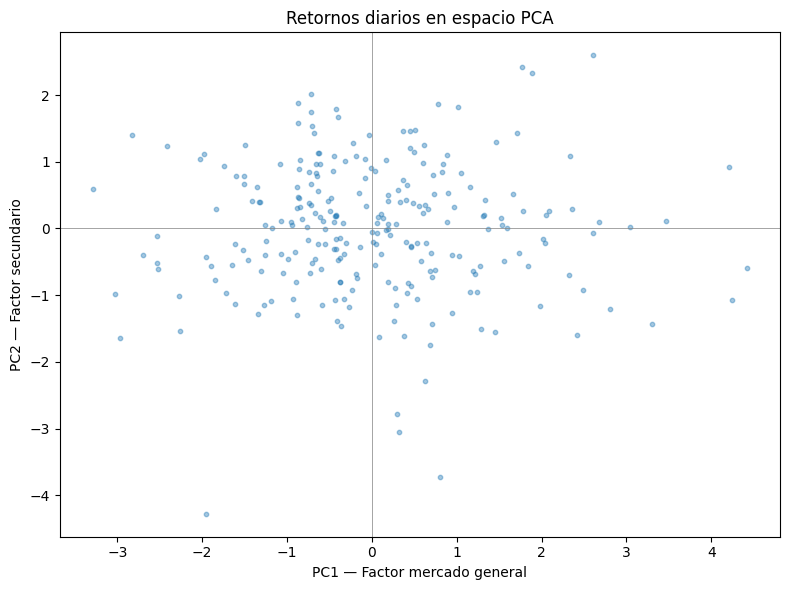

In [38]:
# Proyectar retornos sobre componentes principales
# (transformar datos al espacio PCA)
from sklearn.preprocessing import StandardScaler

# Estandarizar retornos
scaler = StandardScaler()
returns_scaled = scaler.fit_transform(returns)

# Proyectar sobre los 2 primeros PCs
pc_scores = returns_scaled @ eigenvectors_c[:, :2]
pc_scores = pd.DataFrame(pc_scores, 
                          columns=["PC1_mercado", "PC2_tech_vs_oro"],
                          index=returns.index)

# Correlación de cada PC con los activos originales
print("Correlación PC1 con cada activo:")
for ticker in tickers:
    corr = pc_scores["PC1_mercado"].corr(returns[ticker])
    print(f"  {ticker}: {corr:.3f}")

print("\nCorrelación PC2 con cada activo:")
for ticker in tickers:
    corr = pc_scores["PC2_tech_vs_oro"].corr(returns[ticker])
    print(f"  {ticker}: {corr:.3f}")

# Gráfica de los retornos proyectados en el espacio PC1-PC2
plt.figure(figsize=(8,6))
plt.scatter(pc_scores["PC1_mercado"], 
            pc_scores["PC2_tech_vs_oro"], 
            alpha=0.4, s=10)
plt.axhline(0, color='gray', linewidth=0.5)
plt.axvline(0, color='gray', linewidth=0.5)
plt.xlabel("PC1 — Factor mercado general")
plt.ylabel("PC2 — Factor secundario")
plt.title("Retornos diarios en espacio PCA")
plt.tight_layout()
plt.show()

Muy buena interpretación del PC2 — la lógica de "burbuja tech → rotación a oro" es exactamente el tipo de razonamiento que un quant researcher usa para darle nombre a un factor.
Sobre la gráfica, la dispersión mayor en PC1 que en PC2 es consistente con que PC1 explica más varianza (43% vs 24%). Los puntos cerca del origen significan que la mayoría de los días los movimientos son pequeños — los días extremos (crisis, rally fuerte) son los puntos alejados del centro.

PC1 (43% varianza) = Mercado general
   → AAPL, AMZN, TSLA se mueven juntas
   → GLD apenas participa

PC2 (24% varianza) = Rotación de riesgo  
   → GLD sube cuando TSLA baja
   → AAPL y AMZN casi no participan

SyntaxError: invalid syntax (2892320128.py, line 1)